# 🛡️ ToS Shield — Step 2: Fine-Tuning DistilBERT

**Notebook:** `notebooks/02_finetune_distilbert.ipynb`

## What this notebook does
We fine-tune `distilbert-base-uncased` on the `lex_glue/unfair_tos` dataset under **four experimental conditions**, then compare results and explain what each model learned.

---

## Experiment Matrix

| ID | Task | Imbalance Handling | Loss |
|----|------|--------------------|------|
| **A** | 10-class | ❌ None (baseline) | Cross-Entropy |
| **B** | 10-class | ✅ Downsample 2:1 + class weights | Cross-Entropy |
| **C** | Binary (Fair/Unfair) | ✅ Downsample 2:1 + class weights | Cross-Entropy |
| **D** | 10-class | ✅ Downsample 2:1 + class weights | **Focal Loss** γ=2 |

---

## Project structure
```
tos_shield/
├── notebooks/
│   ├── 01_eda_unfair_tos.ipynb
│   └── 02_finetune_distilbert.ipynb   ← YOU ARE HERE
├── src/
│   ├── data_loader.py          load_dataset()
│   ├── training_config.py      ExperimentConfig, EXPERIMENTS dict
│   ├── ft_dataset.py           ToSDataset, FocalLoss, build_dataloaders()
│   ├── ft_trainer.py           DistilBertTrainer  (real GPU training)
│   ├── mock_trainer.py         MockTrainer        (offline / CI)
│   ├── ft_evaluation.py        comparison plots
│   └── ft_explainability.py    attention rollout, IG, SHAP
├── outputs/                    CSVs, figures from Step 1
└── models/                     saved checkpoints (written here)
```


In [ ]:
# Code was run on collab -> for non-colab user skip this cell:

#!git clone https://github.com/nswierkowski/ai-ethics-law-mini-project.git

# %cd ai-ethics-law-mini-project
# %pwd

# import sys
# sys.path.append("/content/ai-ethics-law-mini-project")



Cloning into 'ai-ethics-law-mini-project'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (33/33), done.
remote: Total 38 (delta 1), reused 38 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 740.66 KiB | 2.97 MiB/s, done.
Resolving deltas: 100% (1/1), done.


## 1. Environment Setup

In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))   # project root → src/ importable

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.rcParams["figure.dpi"] = 110

# Optional: check GPU
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"PyTorch  : {torch.__version__}")
    print(f"Device   : {DEVICE}")
    if DEVICE == "cuda":
        print(f"GPU      : {torch.cuda.get_device_name(0)}")
        print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    TORCH_AVAILABLE = True
except ImportError:
    TORCH_AVAILABLE = False
    DEVICE = "cpu"
    print("⚠️  PyTorch not found — will use MockTrainer")

try:
    import transformers
    print(f"Transformers: {transformers.__version__}")
    HF_AVAILABLE = True
except ImportError:
    HF_AVAILABLE = False
    print("⚠️  transformers not found — will use MockTrainer")

print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")


PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4
VRAM     : 15.6 GB
Transformers: 5.0.0
NumPy    : 2.0.2
Pandas   : 2.2.2


## 2. Import from `src/`

In [ ]:
from src.data_loader import load_dataset, LABEL_NAMES, UNFAIR_LABELS

from src.training_config import (
    EXPERIMENTS,         
    MODELS_DIR,
    FIGURES_DIR,
    OUTPUTS_DIR,
    BINARY_LABEL_NAMES,
)

from src.ft_dataset import (
    ToSDataset,
    FocalLoss,
    compute_class_weights_tensor,
)

from src.ft_evaluation import (
    plot_training_curves,
    plot_experiment_comparison,
    plot_confusion_matrices,
    plot_per_class_f1_heatmap,
    results_to_dataframe,
    EXP_SHORT,
)

from src.ft_explainability import (
    attention_rollout,
    integrated_gradients,
    shap_token_importance,
    plot_token_heatmap,
    plot_attention_head_map,
    plot_top_important_tokens,
    plot_comparative_explanations,
    TokenImportance,
)

from src.eda_utils import set_style

print("✓ All imports successful")


✓ All imports successful


## 3. Training Mode Toggle

Set `USE_MOCK = False` to run real fine-tuning (requires PyTorch + transformers + GPU recommended).  
`USE_MOCK = True` is the default — produces realistic simulated results instantly.


In [ ]:
USE_MOCK = not (TORCH_AVAILABLE and HF_AVAILABLE)   # auto-detect
# USE_MOCK = True    # force mock
# USE_MOCK = False   # force real training

if USE_MOCK:
    from src.mock_trainer import MockTrainer as Trainer
    print("🔧 Mode: MockTrainer  (set USE_MOCK=False for real training)")
else:
    from src.ft_trainer import DistilBertTrainer as Trainer
    print(f"🚀 Mode: Real training on {DEVICE}")


🚀 Mode: Real training on cuda


## 4. Load Dataset

In [7]:
splits   = load_dataset(use_mock_fallback=True, seed=42, verbose=True)
train_df = splits["train"].df
val_df   = splits["validation"].df
test_df  = splits["test"].df

print(f"\nTrain : {len(train_df):,}  |  Val : {len(val_df):,}  |  Test : {len(test_df):,}")
print(f"Fair  (train): {train_df['is_unfair'].eq(0).sum():,}  "
      f"({100*train_df['is_unfair'].eq(0).mean():.1f}%)")
print(f"Unfair(train): {train_df['is_unfair'].eq(1).sum():,}  "
      f"({100*train_df['is_unfair'].eq(1).mean():.1f}%)")
train_df.head(3)


📦 Loading lex_glue / unfair_tos from HuggingFace …


README.md: 0.00B [00:00, ?B/s]

unfair_tos/train-00000-of-00001.parquet:   0%|          | 0.00/501k [00:00<?, ?B/s]

unfair_tos/test-00000-of-00001.parquet:   0%|          | 0.00/147k [00:00<?, ?B/s]

unfair_tos/validation-00000-of-00001.par(…):   0%|          | 0.00/218k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/5532 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1607 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2275 [00:00<?, ? examples/s]

 train        → 5,532 samples
 validation   → 2,275 samples
 test         → 1,607 samples

Train : 5,532  |  Val : 2,275  |  Test : 1,607
Fair  (train): 4,902  (88.6%)
Unfair(train): 630  (11.4%)


,text,label,label_name,label_abbr,is_unfair,text_length,word_count,sentence_count
0,notice to california subscribers : you may can...,9,OK / Fair,OB,0,195,33,2
1,"if you subscribed using your apple id , refund...",9,OK / Fair,OB,0,85,17,2
2,"if you wish to request a refund , please visit...",9,OK / Fair,OB,0,79,12,4


## 5. Experiment Configuration Overview

In [8]:
rows = []
for exp_name, cfg in EXPERIMENTS.items():
    rows.append({
        "ID":              EXP_SHORT[exp_name],
        "Task":            cfg.task,
        "Num Labels":      cfg.num_labels,
        "Handle Imbalance":cfg.handle_imbalance,
        "Focal Loss":      cfg.use_focal_loss,
        "Downsample Ratio":cfg.downsample_ratio,
        "Epochs":          cfg.num_epochs,
        "Batch Size":      cfg.batch_size,
        "LR":              cfg.learning_rate,
        "Max Seq Len":     cfg.max_length,
    })
pd.DataFrame(rows)


,ID,Task,Num Labels,Handle Imbalance,Focal Loss,Downsample Ratio,Epochs,Batch Size,LR,Max Seq Len
0,A: Baseline,multiclass,10,False,False,NaN,30,16,0.00002,128
1,B: Balanced,multiclass,10,True,False,2.0,30,16,0.00002,128
2,C: Binary,binary,2,True,False,2.0,30,16,0.00002,128
3,D: Focal,multiclass,10,True,True,2.0,30,16,0.00002,128


## 6. Focal Loss — Quick Primer

Focal Loss (Lin et al., ICCV 2017) down-weights easy examples so the model focuses on hard, minority-class samples:

$$FL(p_t) = -\alpha_t \cdot (1 - p_t)^{\gamma} \cdot \log(p_t)$$

- When a sample is **easy** (high $p_t$), the modulating factor $(1-p_t)^\gamma$ is near 0 → small gradient.
- When a sample is **hard** (low $p_t$), the factor is near 1 → full gradient signal.
- $\gamma = 0$ recovers standard cross-entropy.
- We combine it with per-class $\alpha_t$ weights for double imbalance correction.


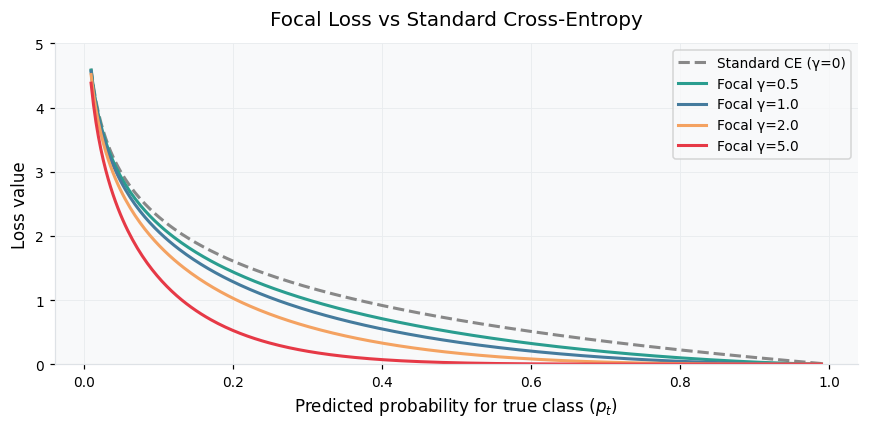

γ=2 gives ~4× less weight to easy (p_t > 0.8) vs hard (p_t < 0.2) examples


In [17]:
# Visualise focal loss modulating factor vs CE
set_style()
fig, ax = plt.subplots(figsize=(8, 4))
pt = np.linspace(0.01, 0.99, 300)

ax.plot(pt, -np.log(pt), color="#888", lw=2, ls="--", label="Standard CE (γ=0)")
for gamma, color in [(0.5, "#2A9D8F"), (1.0, "#457B9D"),
                      (2.0, "#F4A261"), (5.0, "#E63946")]:
    fl = -(1 - pt) ** gamma * np.log(pt)
    ax.plot(pt, fl, lw=2, color=color, label=f"Focal γ={gamma}")

ax.set_xlabel("Predicted probability for true class ($p_t$)")
ax.set_ylabel("Loss value")
ax.set_title("Focal Loss vs Standard Cross-Entropy", pad=12)
ax.legend(fontsize=9)
ax.set_ylim(0, 5)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/focal_loss_curves.png", bbox_inches="tight", dpi=130)
plt.show()
print("γ=2 gives ~4× less weight to easy (p_t > 0.8) vs hard (p_t < 0.2) examples")


## 7. Run All Four Experiments

Each experiment uses the same `Trainer` interface (`DistilBertTrainer` or `MockTrainer`).  
Results are stored in the `results` dict keyed by experiment name.


In [9]:
results = {}

for exp_name, cfg in EXPERIMENTS.items():
    print(f"\n{'='*60}")
    print(f"Experiment: {EXP_SHORT[exp_name]}")
    print(f"  {cfg.description}")
    print(f"{'='*60}")

    trainer = Trainer(
        cfg      = cfg,
        train_df = train_df,
        val_df   = val_df,
        test_df  = test_df,
        device   = DEVICE,
    )
    results[exp_name] = trainer.run()

print("\n✅ All experiments complete.")
print(f"   Models saved to: {MODELS_DIR}/")



Experiment: A: Baseline
  10-class DistilBERT — NO imbalance handling (pure baseline)
  Device            : cuda
  Classifier dropout: 0.3
  Early stopping    : patience=3, min_delta=0.001


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch  1/30  train_loss=1.6631  val_loss=0.7007  val_macro_f1=0.0195 ◀ best
  Epoch  2/30  train_loss=1.2776  val_loss=0.4202  val_macro_f1=0.2069 ◀ best
  Epoch  3/30  train_loss=0.5072  val_loss=0.1459  val_macro_f1=0.4487 ◀ best
  Epoch  4/30  train_loss=0.1753  val_loss=0.1259  val_macro_f1=0.5034 ◀ best
  Epoch  5/30  train_loss=0.0749  val_loss=0.1220  val_macro_f1=0.5752 ◀ best
  Epoch  6/30  train_loss=0.0382  val_loss=0.1340  val_macro_f1=0.5862 ◀ best
  Epoch  7/30  train_loss=0.0253  val_loss=0.1721  val_macro_f1=0.6317 ◀ best
  Epoch  8/30  train_loss=0.0127  val_loss=0.1415  val_macro_f1=0.5922  [ES wait 1/3]
  Epoch  9/30  train_loss=0.0061  val_loss=0.1669  val_macro_f1=0.5816  [ES wait 2/3]
  Epoch 10/30  train_loss=0.0047  val_loss=0.1451  val_macro_f1=0.5655  [ES wait 3/3]

  ⏹  Early stopping triggered after epoch 10  (no improvement for 3 epochs).
     Best val macro-F1 = 0.6317 @ epoch 7
  ↩  Restored best weights from epoch 7


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  💾 Saved → /content/ai-ethics-law-mini-project/models/D_multiclass_focal

  ✅ Done in 5.8 min  | epochs=10/30  | early_stopped=True  | best val macro-F1=0.6317  | test macro-F1=0.6343

✅ All experiments complete.
   Models saved to: /content/ai-ethics-law-mini-project/models/


## 8. Training Curves

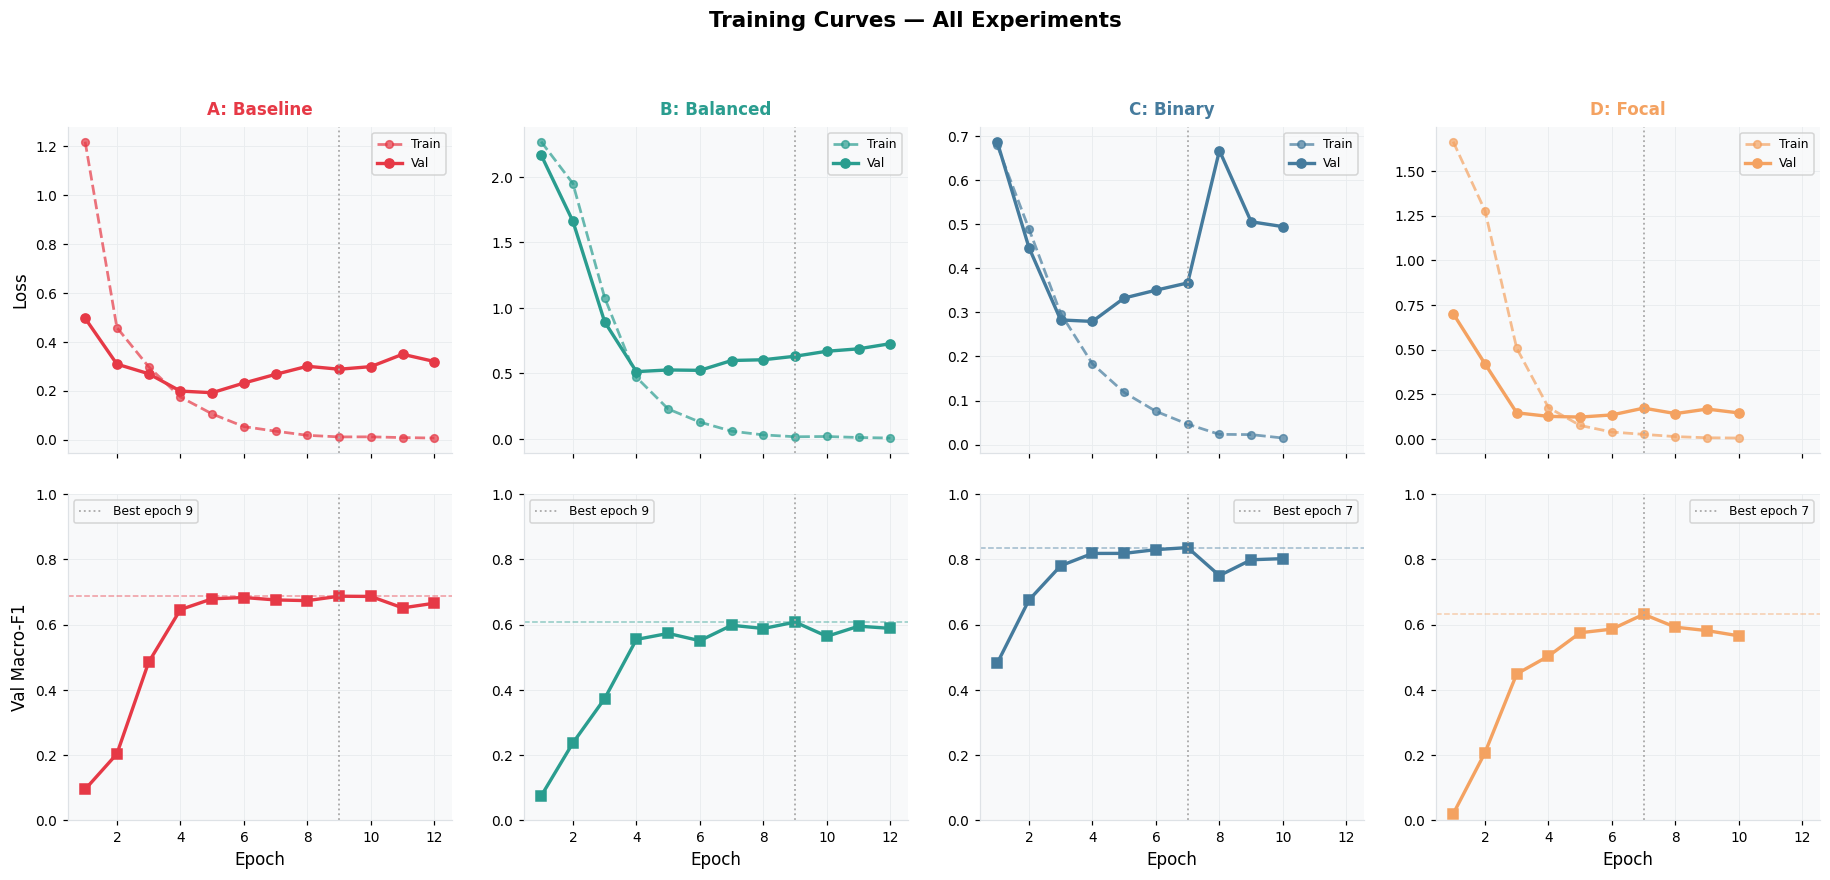

In [11]:
fig = plot_training_curves(results, figsize=(17, 8))
fig.savefig(f"{FIGURES_DIR}/training_curves.png", bbox_inches="tight", dpi=130)
plt.show()


## 9. Results Summary Table

In [12]:
summary_df = results_to_dataframe(results)
summary_df


,Experiment,Task,Imbalance Handled,Loss,Downsampled,Best Val Macro-F1,Best Epoch,Early Stopped,Epochs Trained,Test Accuracy,Test Macro-F1,Test Weighted-F1,Train Time (min)
0,A: Baseline,multiclass,False,CrossEntropy,False,0.6872,9,True,12,0.9490,0.6867,0.9480,15.6
1,B: Balanced,multiclass,True,CrossEntropy,True,0.6078,9,True,12,0.9141,0.6321,0.9245,6.8
2,C: Binary,binary,True,CrossEntropy,True,0.8363,7,True,10,0.9378,0.8534,0.9408,5.7
3,D: Focal,multiclass,True,Focal,True,0.6317,7,True,10,0.9235,0.6343,0.9296,5.8


In [ ]:
def highlight_max(s):
    is_max = s == s.max()
    return ["background-color: #d4f7d4; font-weight: bold" if v else "" for v in is_max]

numeric_cols = ["Best Val Macro-F1", "Test Accuracy", "Test Macro-F1", "Test Weighted-F1"]
summary_df.style.apply(highlight_max, subset=numeric_cols)


,Experiment,Task,Imbalance Handled,Loss,Downsampled,Best Val Macro-F1,Best Epoch,Early Stopped,Epochs Trained,Test Accuracy,Test Macro-F1,Test Weighted-F1,Train Time (min)
0,A: Baseline,multiclass,False,CrossEntropy,False,0.687200,9,True,12,0.949000,0.686700,0.948000,15.600000
1,B: Balanced,multiclass,True,CrossEntropy,True,0.607800,9,True,12,0.914100,0.632100,0.924500,6.800000
2,C: Binary,binary,True,CrossEntropy,True,0.836300,7,True,10,0.937800,0.853400,0.940800,5.700000
3,D: Focal,multiclass,True,Focal,True,0.631700,7,True,10,0.923500,0.634300,0.929600,5.800000


## 10. Performance Comparison Chart

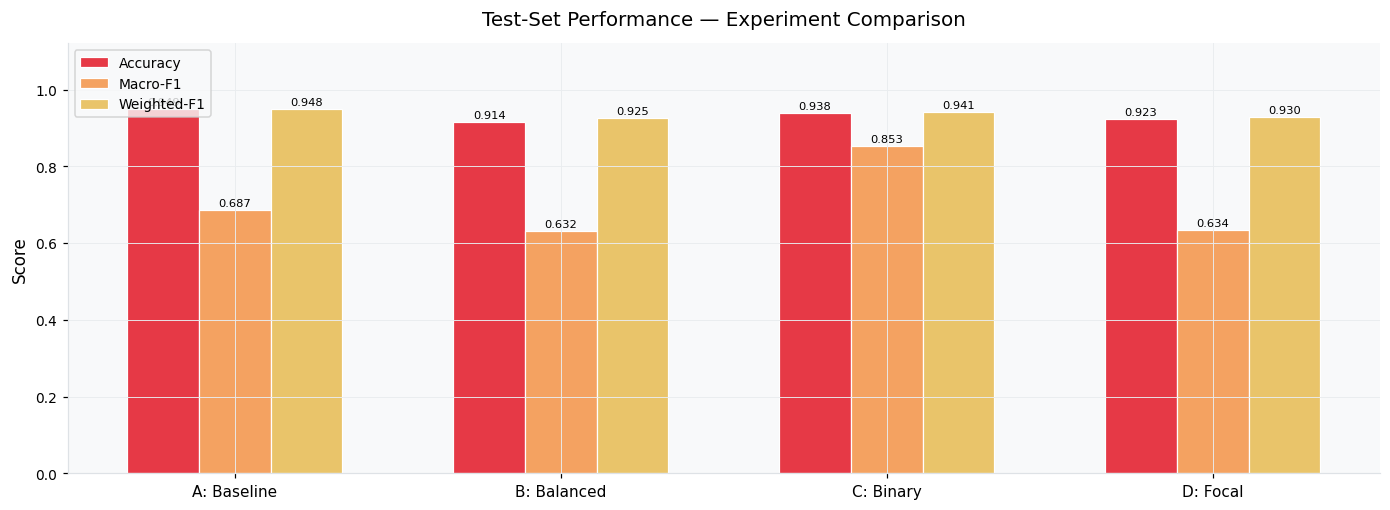

In [14]:
fig = plot_experiment_comparison(results)
fig.savefig(f"{FIGURES_DIR}/experiment_comparison.png", bbox_inches="tight", dpi=130)
plt.show()


## 11. Classification Reports (per experiment)

In [15]:
for exp_name, res in results.items():
    print(f"\n{'─'*55}")
    print(f"  {EXP_SHORT[exp_name]}")
    print(f"{'─'*55}")
    print(res.classification_rep)



───────────────────────────────────────────────────────
  A: Baseline
───────────────────────────────────────────────────────
                         precision    recall  f1-score   support

            Arbitration       0.75      0.67      0.71        36
        Content Removal       0.54      0.54      0.54        28
           Copyright/IP       0.88      0.55      0.68        38
           Jurisdiction       0.55      0.92      0.69        13
          Governing Law       0.83      0.68      0.75        22
Limitation of Liability       0.86      0.92      0.89        13
 Unilateral Termination       0.93      0.87      0.90        15
         Broad Data Use       0.67      0.86      0.75         7
         Privacy Change       0.00      0.00      0.00         0
              OK / Fair       0.97      0.98      0.98      1435

               accuracy                           0.95      1607
              macro avg       0.70      0.70      0.69      1607
           weighted avg   

## 12. Confusion Matrices

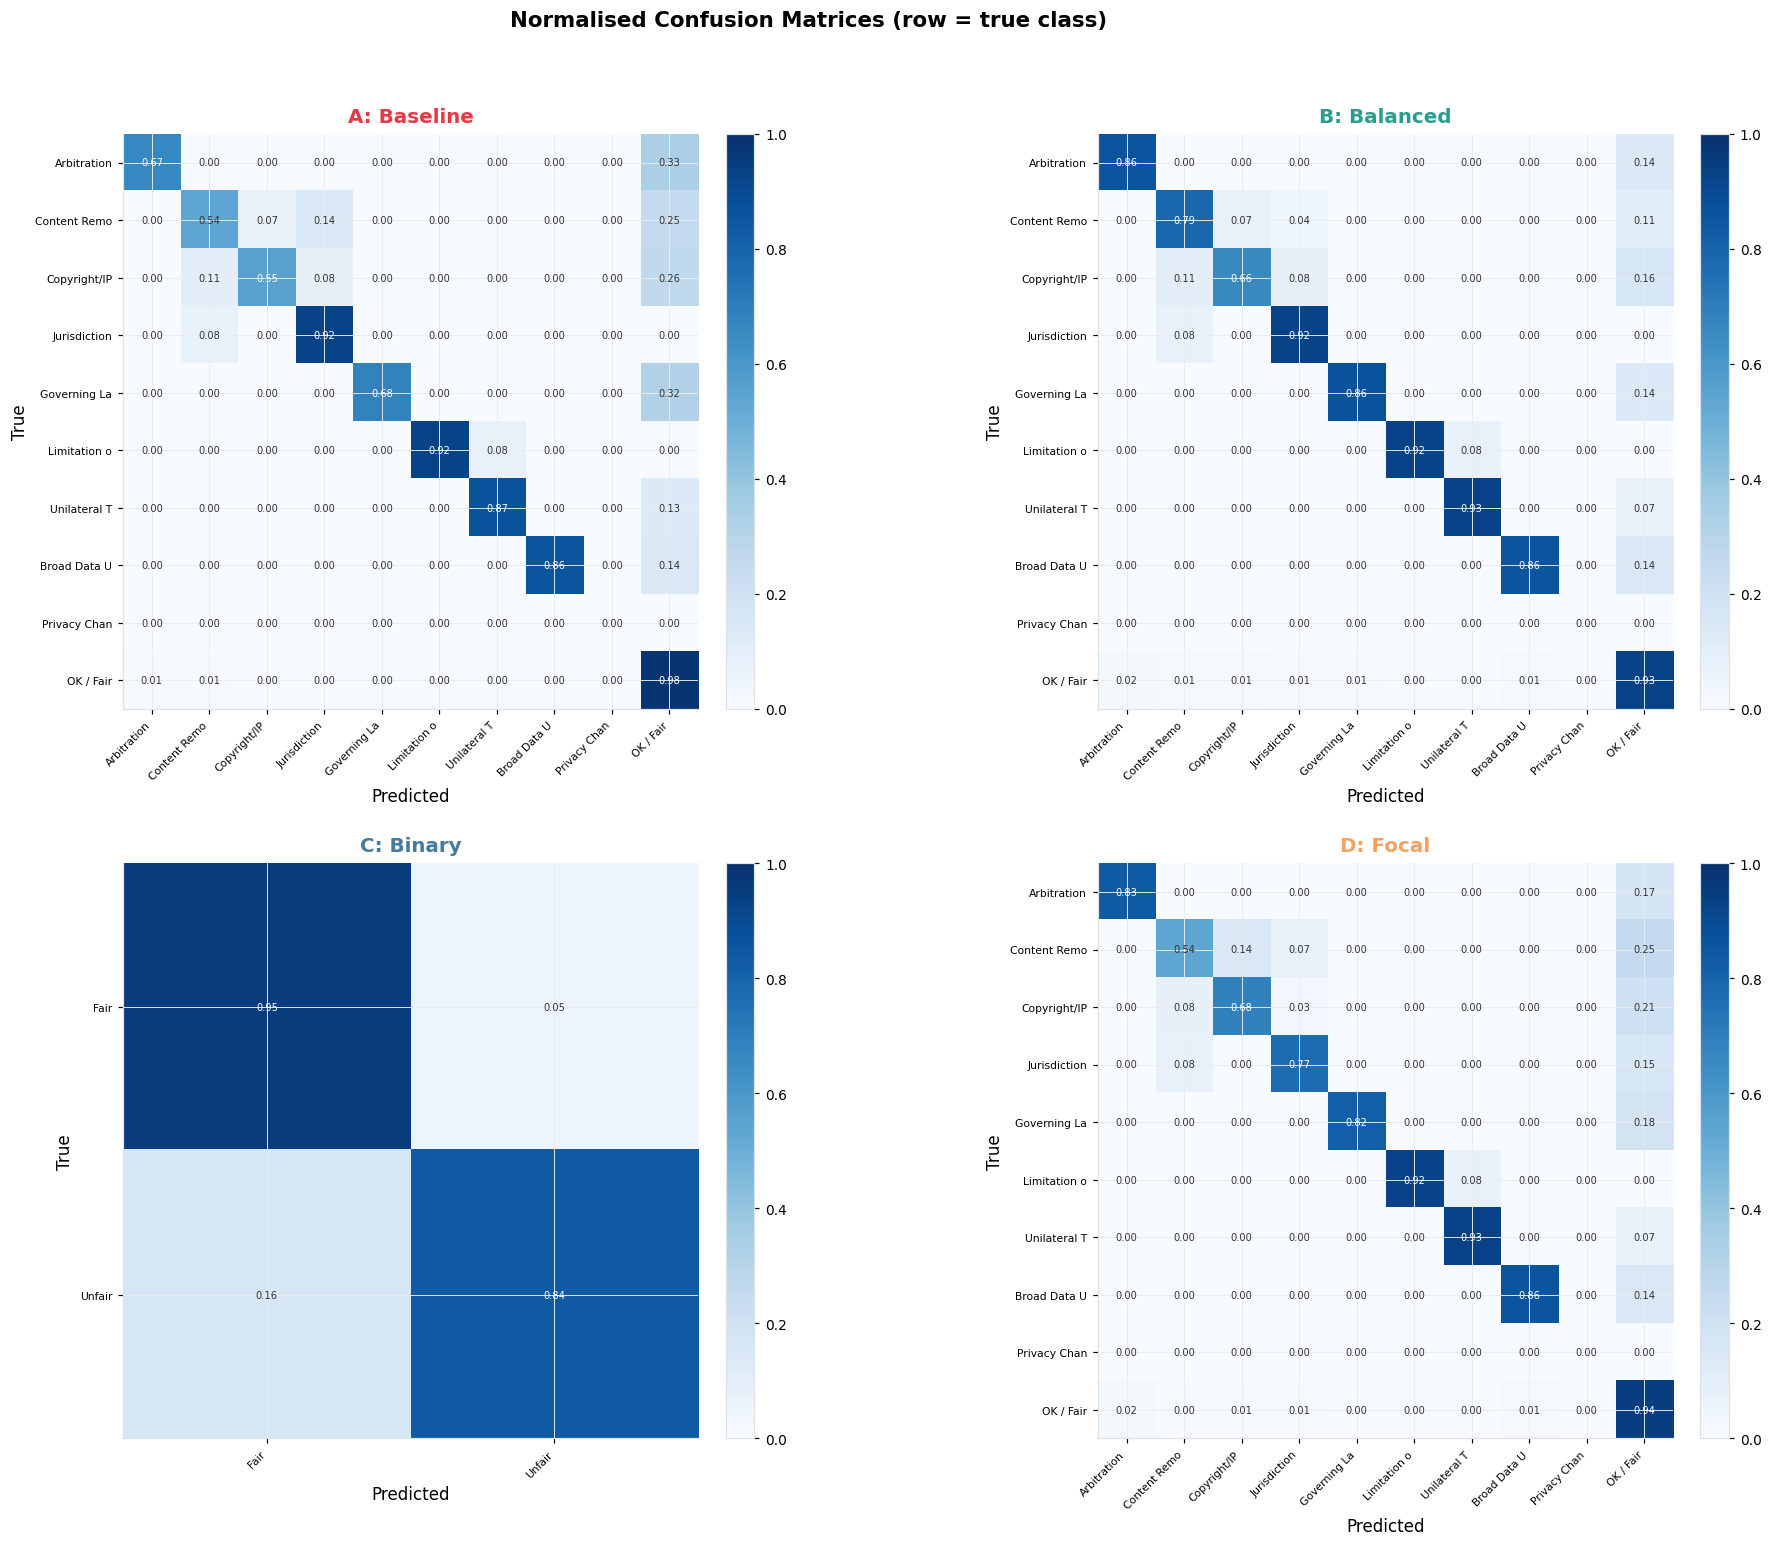

In [16]:
fig = plot_confusion_matrices(results, figsize=(18, 14))
fig.savefig(f"{FIGURES_DIR}/confusion_matrices.png", bbox_inches="tight", dpi=130)
plt.show()


## 13. Per-Class F1 Heatmap

Which clause types improve most when we handle imbalance?  
Expected pattern: rare classes (Governing Law, Jurisdiction) show the biggest gains in B vs A.


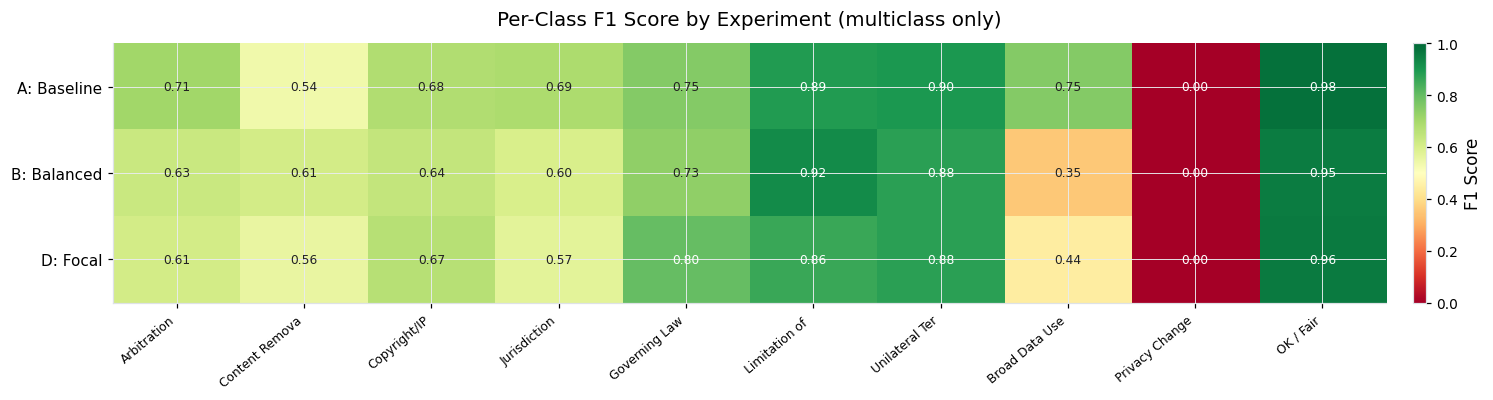

In [17]:
fig = plot_per_class_f1_heatmap(results, figsize=(14, 4))
fig.savefig(f"{FIGURES_DIR}/per_class_f1_heatmap.png", bbox_inches="tight", dpi=130)
plt.show()


In [18]:
# Quantify improvement A → B per class (multiclass only)
res_A = results["A_multiclass_baseline"]
res_B = results["B_multiclass_balanced"]
res_D = results["D_multiclass_focal"]

delta_df = pd.DataFrame({
    "Class":           list(LABEL_NAMES.values()),
    "F1 (A: Baseline)":list(res_A.per_class_f1.values()),
    "F1 (B: Balanced)":list(res_B.per_class_f1.values()),
    "F1 (D: Focal)":   list(res_D.per_class_f1.values()),
})
delta_df["Δ B−A"] = (delta_df["F1 (B: Balanced)"] - delta_df["F1 (A: Baseline)"]).round(3)
delta_df["Δ D−A"] = (delta_df["F1 (D: Focal)"]   - delta_df["F1 (A: Baseline)"]).round(3)
delta_df = delta_df.sort_values("Δ B−A", ascending=False)
delta_df


,Class,F1 (A: Baseline),F1 (B: Balanced),F1 (D: Focal),Δ B−A,Δ D−A
1,Content Removal,0.535714,0.611111,0.555556,0.075,0.020
5,Limitation of Liability,0.888889,0.923077,0.857143,0.034,-0.032
8,Privacy Change,0.000000,0.000000,0.000000,0.000,0.000
4,Governing Law,0.750000,0.730769,0.800000,-0.019,0.050
9,OK / Fair,0.976744,0.954709,0.960596,-0.022,-0.016
6,Unilateral Termination,0.896552,0.875000,0.875000,-0.022,-0.022
2,Copyright/IP,0.677419,0.641026,0.666667,-0.036,-0.011
0,Arbitration,0.705882,0.632653,0.612245,-0.073,-0.094
3,Jurisdiction,0.685714,0.600000,0.571429,-0.086,-0.114
7,Broad Data Use,0.750000,0.352941,0.444444,-0.397,-0.306


## 14. Select Best Models for Explainability

We pick:
- **Best multiclass model** (highest test macro-F1 among A/B/D)
- **Binary model** (C) — for comparison since it has a different label space

Both are then fed to three explainability lenses.


In [19]:
# Best multiclass
mc_results = {k: v for k, v in results.items() if not v.cfg.is_binary}
best_mc_name = max(mc_results, key=lambda k: mc_results[k].test_macro_f1)
best_mc_res  = mc_results[best_mc_name]

print(f"Best multiclass model : {EXP_SHORT[best_mc_name]}")
print(f"  Test macro-F1       : {best_mc_res.test_macro_f1:.4f}")
print(f"  Test accuracy       : {best_mc_res.test_accuracy:.4f}")
print()
print(f"Binary model          : {EXP_SHORT['C_binary_balanced']}")
print(f"  Test macro-F1       : {results['C_binary_balanced'].test_macro_f1:.4f}")


Best multiclass model : A: Baseline
  Test macro-F1       : 0.6867
  Test accuracy       : 0.9490

Binary model          : C: Binary
  Test macro-F1       : 0.8534


## 15. Attention Rollout — Single Examples

**Attention rollout** (Abnar & Zuidema, 2020) propagates attention through all layers:

$$R_l = R_{l-1} \cdot \left(0.5 A_l + 0.5 I\right)$$

The CLS token's final importance vector tells us which words drove the classification.


In [20]:
# Sample one example per unfair class + one fair example
sample_examples = []
for lbl in list(UNFAIR_LABELS)[:4] + [9]:
    sub = test_df[test_df["label"] == lbl]
    if len(sub) > 0:
        row = sub.sample(1, random_state=42).iloc[0]
        sample_examples.append((row["text"], lbl))

print(f"Selected {len(sample_examples)} examples for explanation")


Selected 5 examples for explanation


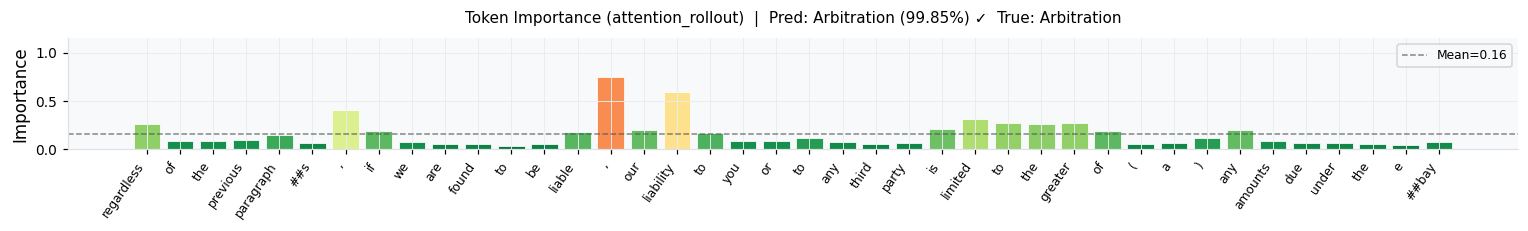

  True: Arbitration                Pred: Arbitration                Conf: 99.85%



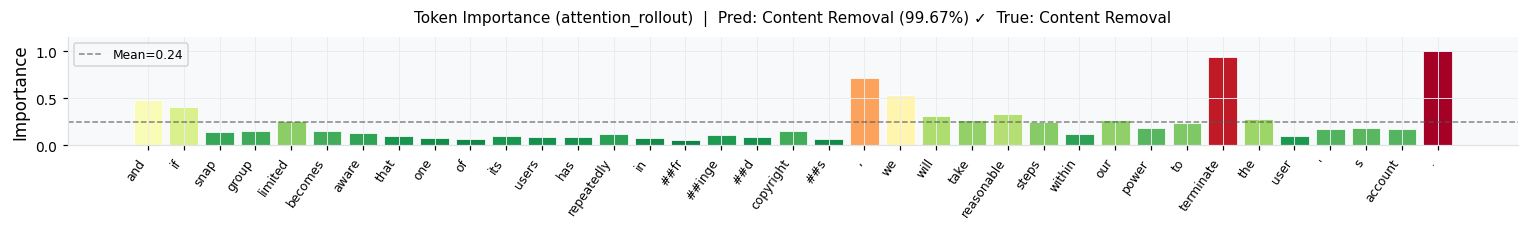

  True: Content Removal            Pred: Content Removal            Conf: 99.67%



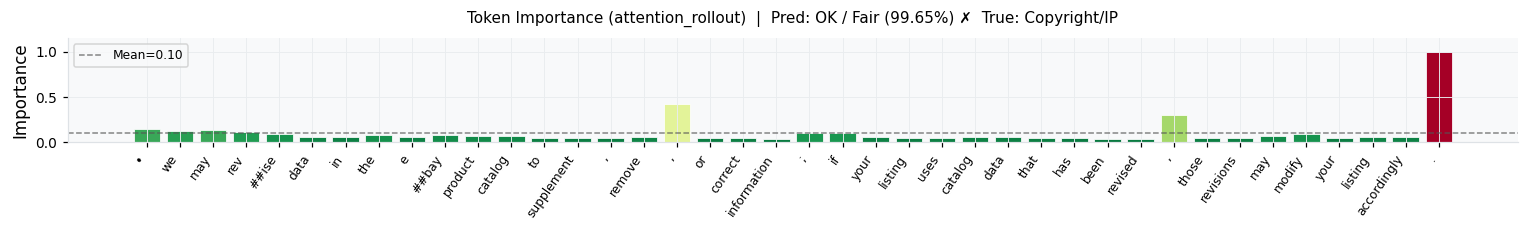

  True: Copyright/IP               Pred: OK / Fair                  Conf: 99.65%



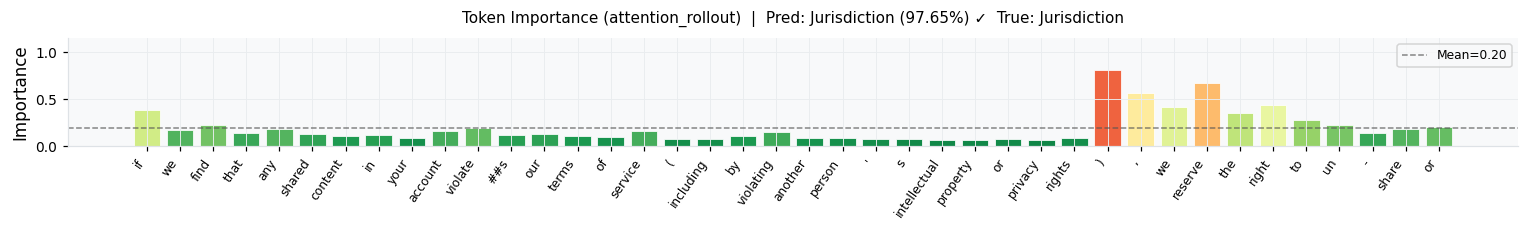

  True: Jurisdiction               Pred: Jurisdiction               Conf: 97.65%



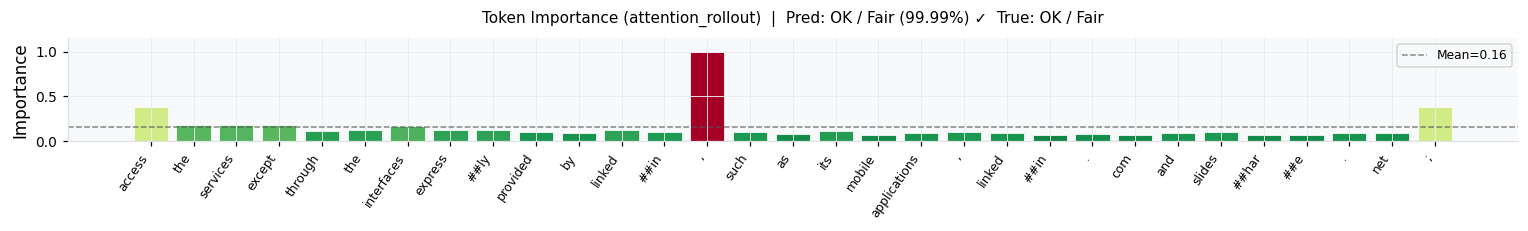

  True: OK / Fair                  Pred: OK / Fair                  Conf: 99.99%



In [21]:
# Explain with attention rollout using best multiclass model
rollout_results = []
best_mc_res.model.config.output_attentions = True

for text, true_lbl in sample_examples:
    ti = attention_rollout(
        model      = best_mc_res.model,
        tokenizer  = best_mc_res.tokenizer,
        text       = text,
        true_label = true_lbl,
        device     = DEVICE,
    )
    rollout_results.append(ti)

    fig = plot_token_heatmap(ti, label_names=LABEL_NAMES)
    plt.show()
    print(f"  True: {LABEL_NAMES[true_lbl]:25s}  "
          f"Pred: {LABEL_NAMES[ti.pred_label]:25s}  "
          f"Conf: {ti.pred_prob:.2%}")
    print()


## 16. Attention Head Maps

Raw multi-head attention at the last layer for one clause.  
Different heads specialise in different syntactic/semantic relationships.


regardless of the previous paragraphs , if we are found to be liable , our liability to you or to any third party is limited to the greater of ( a ) any amounts due under the ebay money back guarantee up to the price the item sold for on ebay ( including any applicable sales tax ) and its original shipping costs , ( b ) the amount of fees in dispute not to exceed the total fees , which you paid to us in the 12 months prior to the action giving rise to the liability , or ( c ) $ 100 . 



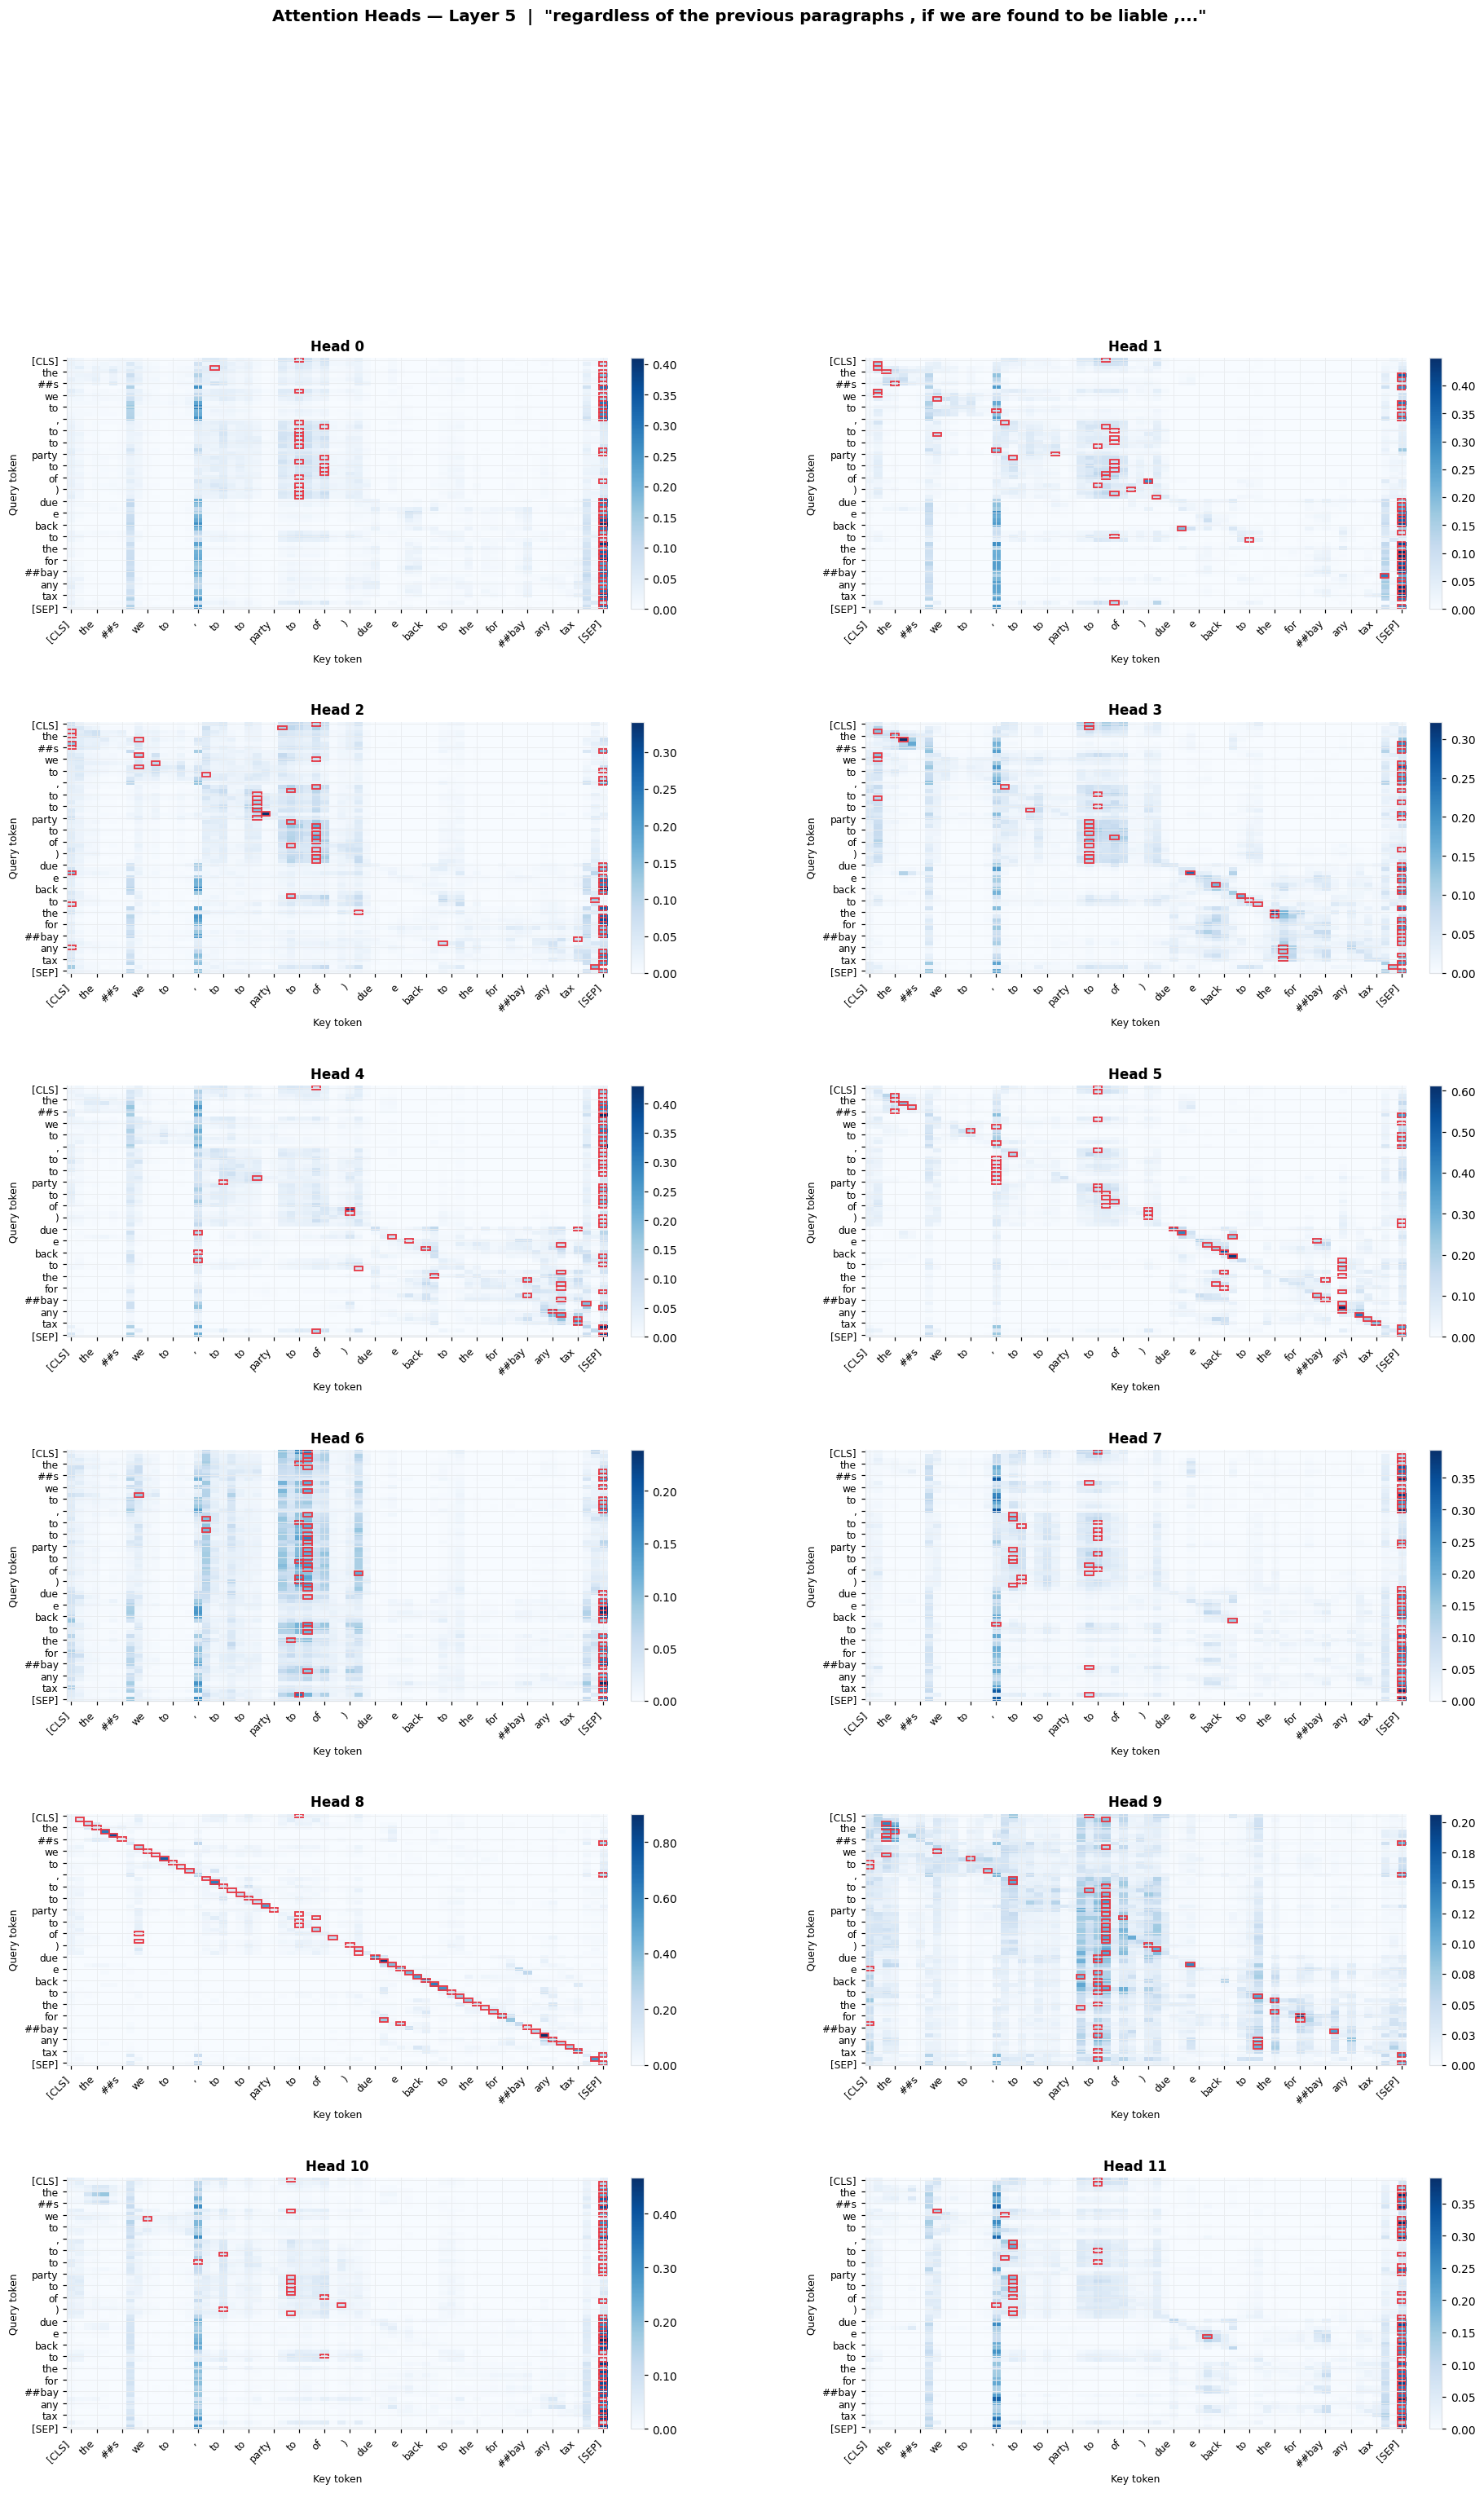

In [25]:
example_text, example_lbl = sample_examples[0]  # first unfair example

print(example_text)
fig = plot_attention_head_map(
    model     = best_mc_res.model,
    tokenizer = best_mc_res.tokenizer,
    text      = example_text,
    layer     = 5,           # last DistilBERT layer (0-indexed)
    device    = DEVICE,
    figsize   = (20, 30),
)
fig.savefig(f"{FIGURES_DIR}/attention_heads_layer5.png", bbox_inches="tight", dpi=130)
plt.show()


## 17. Integrated Gradients

**Integrated Gradients** (Sundararajan et al., 2017) computes the path integral of gradients from a baseline (zero embedding) to the actual input:

$$\text{IG}_i(x) = (x_i - x'_i) \times \int_0^1 \frac{\partial F(x' + \alpha(x-x'))}{\partial x_i} d\alpha$$

Attribution per token = L2 norm of its embedding IG vector.  
More **faithful** than attention (directly tied to model outputs via gradients).


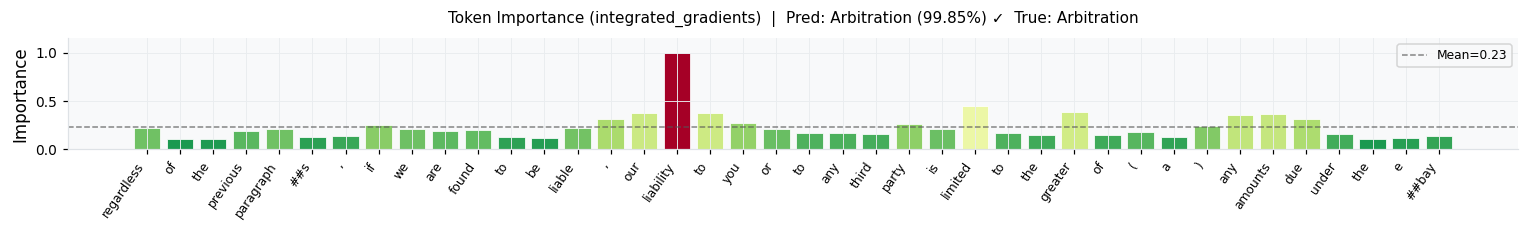

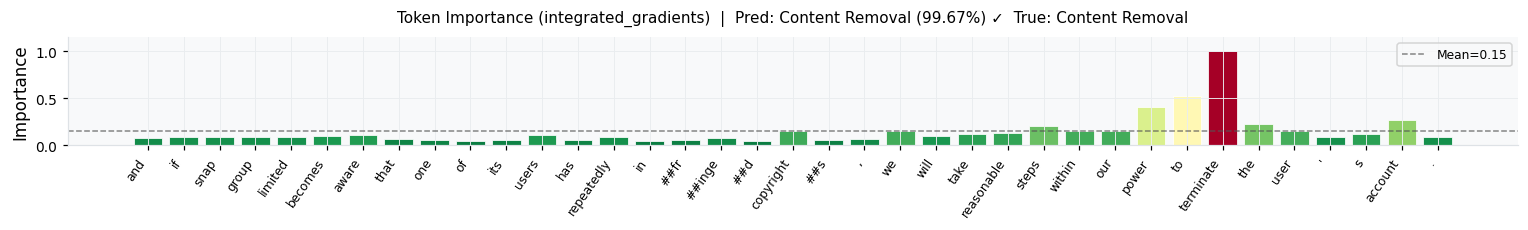

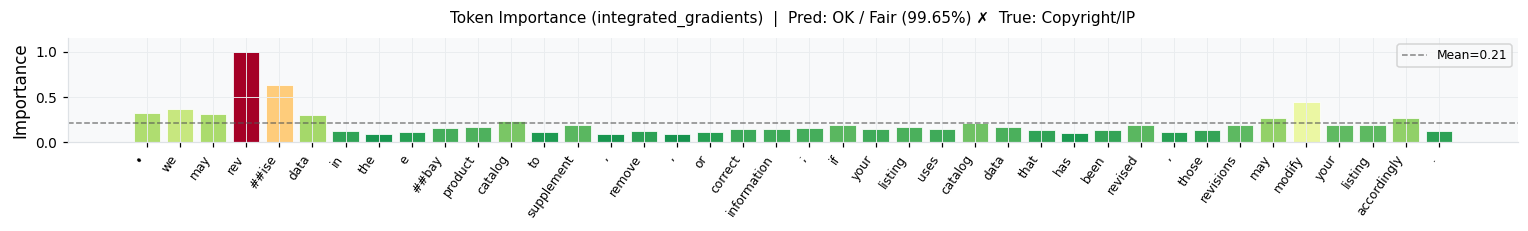

In [27]:
ig_results = []
for text, true_lbl in sample_examples[:3]:
    ti = integrated_gradients(
        model      = best_mc_res.model,
        tokenizer  = best_mc_res.tokenizer,
        text       = text,
        true_label = true_lbl,
        n_steps    = 50,
        device     = DEVICE,
    )
    ig_results.append(ti)

    fig = plot_token_heatmap(ti, label_names=LABEL_NAMES)
    plt.show()


## 18. SHAP — Token Occlusion / KernelExplainer

**SHAP** (Lundberg & Lee, 2017) treats the model as a black box and assigns each token a Shapley value — the average marginal contribution of that token across all possible subsets.

- With `shap` installed: uses `KernelExplainer` for theoretically grounded Shapley values.
- Without `shap`: falls back to **Leave-One-Out** (LOO) occlusion — still interpretable.

$$\phi_i = \sum_{S \subseteq F \setminus \{i\}} \frac{|S|!(|F|-|S|-1)!}{|F|!} \left[ f(S \cup \{i\}) - f(S) \right]$$


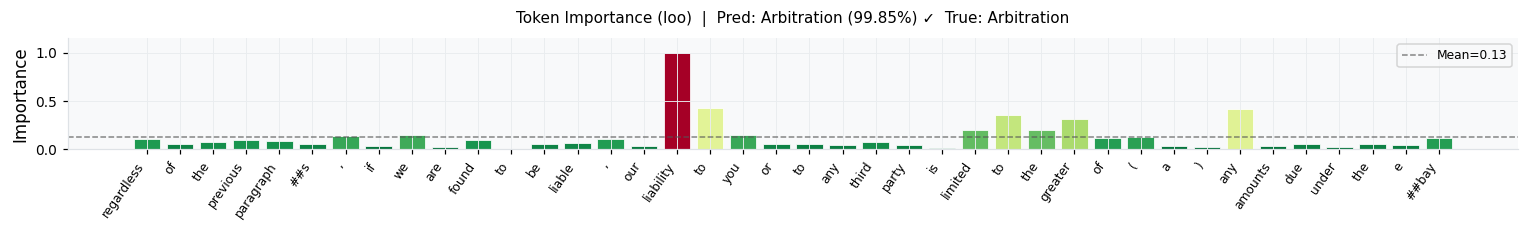

  Method used: loo


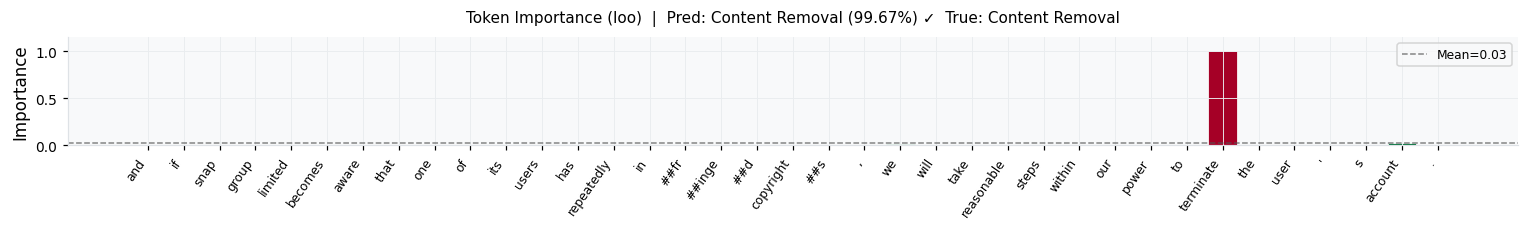

  Method used: loo


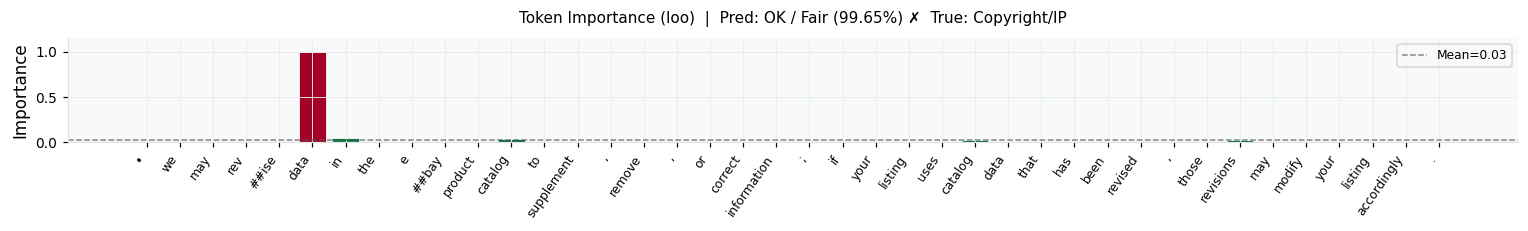

  Method used: loo


In [29]:
shap_results = []
for text, true_lbl in sample_examples[:3]:
    ti = shap_token_importance(
        model      = best_mc_res.model,
        tokenizer  = best_mc_res.tokenizer,
        text       = text,
        true_label = true_lbl,
        n_samples  = 64,   # number of KernelSHAP coalition samples
        device     = DEVICE,
    )
    shap_results.append(ti)

    fig = plot_token_heatmap(ti, label_names=LABEL_NAMES)
    plt.show()
    print(f"  Method used: {ti.method}")


## 19. Explainability Method Comparison — Same Input

Do all three methods agree on which tokens matter?  
Disagreements reveal limitations of each approach.


Input: regardless of the previous paragraphs , if we are found to be liable , our liability to you or to any third party is limited to the greater of ( a ) any amounts due under the ebay money back guarantee up to the price the item sold for on ebay ( including any applicable sales tax ) and its original shipping costs , ( b ) the amount of fees in dispute not to exceed the total fees , which you paid to us in the 12 months prior to the action giving rise to the liability , or ( c ) $ 100 . 

True label: Arbitration



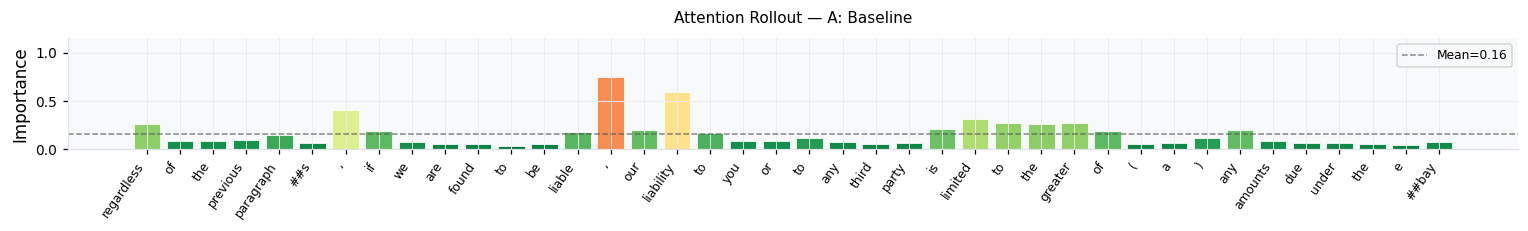

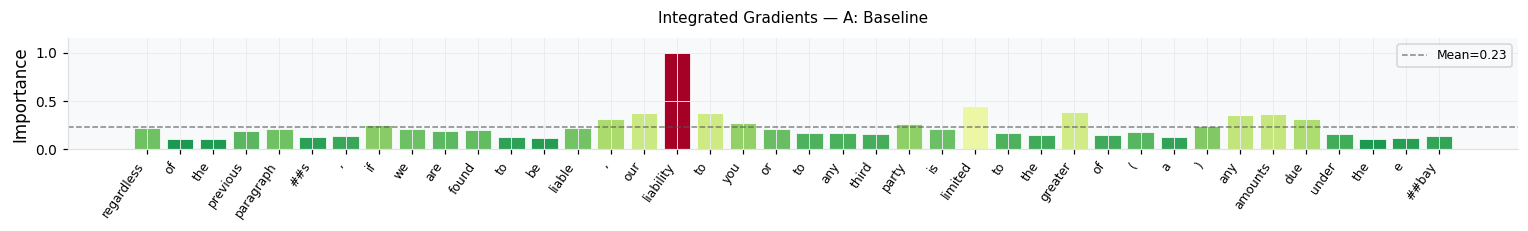

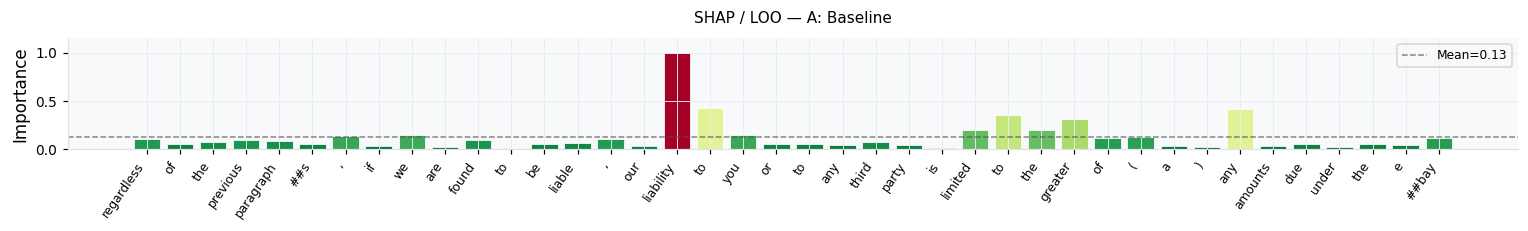

In [30]:
text_to_explain, lbl_to_explain = sample_examples[0]
print(f"Input: {text_to_explain}")
print(f"True label: {LABEL_NAMES[lbl_to_explain]}")
print()

method_results = {}
for method_name, fn in [
    ("Attention Rollout",    attention_rollout),
    ("Integrated Gradients", integrated_gradients),
    ("SHAP / LOO",           shap_token_importance),
]:
    ti = fn(
        model      = best_mc_res.model,
        tokenizer  = best_mc_res.tokenizer,
        text       = text_to_explain,
        true_label = lbl_to_explain,
        device     = DEVICE,
    )
    method_results[method_name] = ti

    fig = plot_token_heatmap(ti, label_names=LABEL_NAMES,
                              title=f"{method_name} — {EXP_SHORT[best_mc_name]}")
    plt.show()


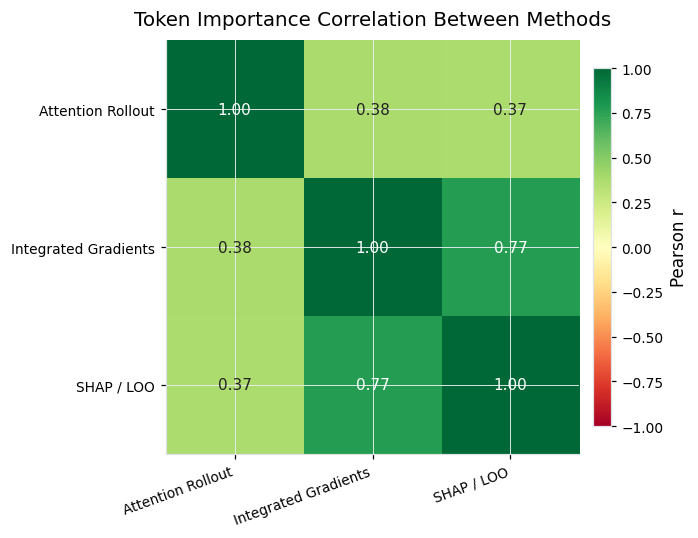

In [31]:
# Correlation between methods
tokens = method_results["Attention Rollout"].tokens
n = len(tokens)
scores_mat = np.array([
    method_results[m].scores[:n] for m in method_results
])
corr = np.corrcoef(scores_mat)

set_style()
fig, ax = plt.subplots(figsize=(6, 5))
method_labels = list(method_results.keys())
im = ax.imshow(corr, cmap="RdYlGn", vmin=-1, vmax=1)
ax.set_xticks(range(len(method_labels)))
ax.set_yticks(range(len(method_labels)))
ax.set_xticklabels(method_labels, rotation=20, ha="right", fontsize=9)
ax.set_yticklabels(method_labels, fontsize=9)
for i in range(len(method_labels)):
    for j in range(len(method_labels)):
        ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center",
                fontsize=10, color="white" if abs(corr[i,j]) > 0.5 else "#222")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.03, label="Pearson r")
ax.set_title("Token Importance Correlation Between Methods", pad=10)
fig.tight_layout()
fig.savefig(f"{FIGURES_DIR}/method_correlation.png", bbox_inches="tight", dpi=130)
plt.show()


## 20. Global Token Importance

Which words are most important **across the entire test set**?  
We aggregate rollout scores over 200 samples to identify corpus-level patterns.


In [33]:
# Sample 200 test examples with balance between fair/unfair
n_per_group = 100
fair_sample   = test_df[test_df["is_unfair"] == 0].sample(
    min(n_per_group, test_df["is_unfair"].eq(0).sum()), random_state=42)
unfair_sample = test_df[test_df["is_unfair"] == 1].sample(
    min(n_per_group, test_df["is_unfair"].eq(1).sum()), random_state=42)
corpus_sample = pd.concat([fair_sample, unfair_sample]).reset_index(drop=True)

print(f"Corpus sample: {len(corpus_sample)} examples  "
      f"(fair={len(fair_sample)}, unfair={len(unfair_sample)})")


Corpus sample: 200 examples  (fair=100, unfair=100)


In [34]:
corpus_token_importances = []

for _, row in corpus_sample.iterrows():
    ti = attention_rollout(
        model      = best_mc_res.model,
        tokenizer  = best_mc_res.tokenizer,
        text       = row["text"],
        true_label = int(row["label"]),
        device     = DEVICE,
    )
    corpus_token_importances.append(ti)

print(f"Computed rollout for {len(corpus_token_importances)} examples")


Computed rollout for 200 examples


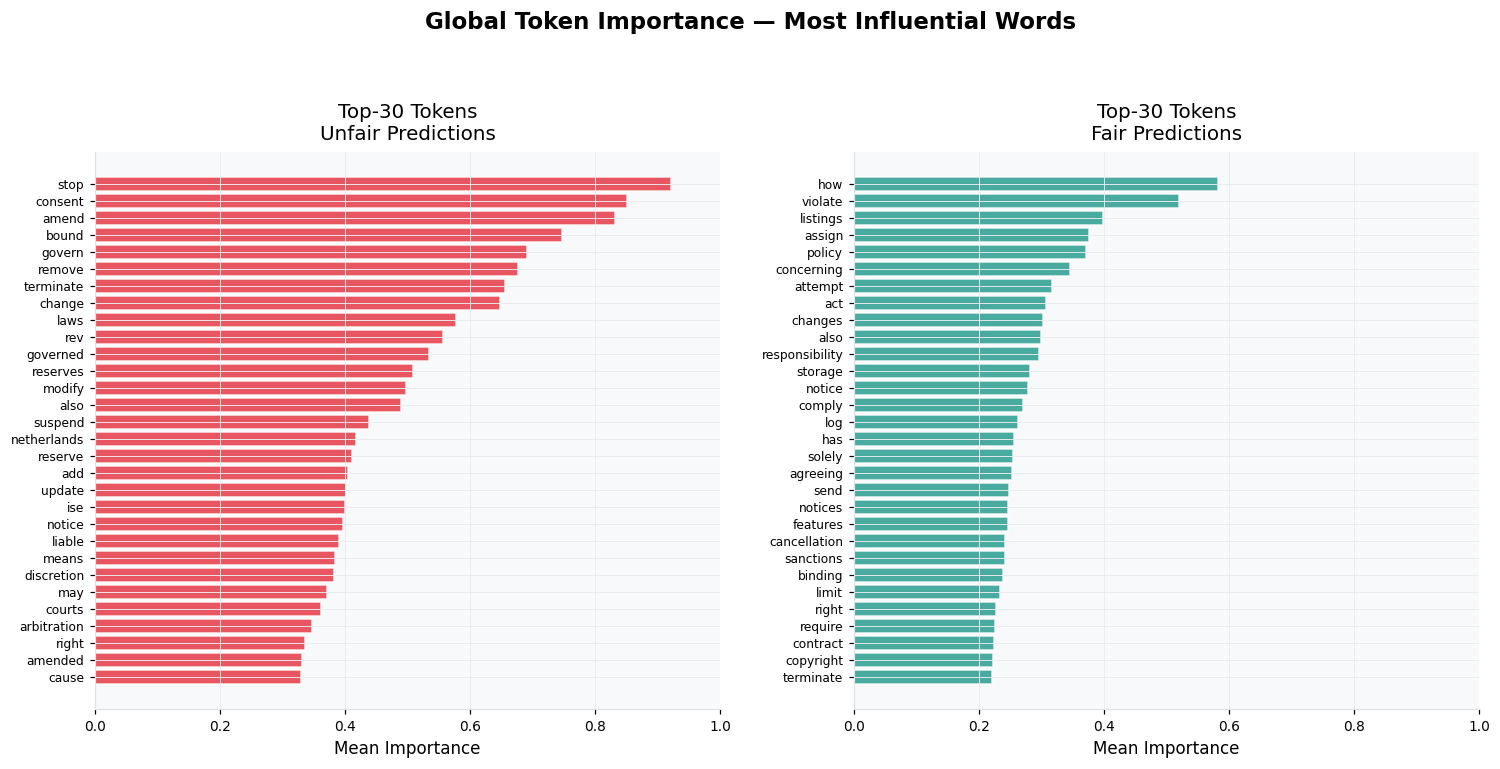

In [35]:
fig = plot_top_important_tokens(
    corpus_token_importances,
    top_k  = 30,
    figsize = (14, 7),
)
fig.savefig(f"{FIGURES_DIR}/global_token_importance.png", bbox_inches="tight", dpi=130)
plt.show()


## 22. Error Analysis — What Does the Best Model Get Wrong?

We look at false negatives (unfair clauses predicted as Fair) — the most dangerous errors for users.


In [36]:
best_res = best_mc_res

# Rebuild test labels/preds aligned with test_df
preds  = best_res.test_preds
labels = best_res.test_labels

# Filter test_df to matching length (mock may differ slightly)
n = min(len(preds), len(test_df))
analysis_df = test_df.iloc[:n].copy().reset_index(drop=True)
analysis_df["pred_label"] = preds[:n]
analysis_df["true_label"] = labels[:n]
analysis_df["correct"]    = analysis_df["pred_label"] == analysis_df["true_label"]

# False Negatives: unfair predicted as Fair
if best_res.cfg.is_binary:
    fn_mask = (analysis_df["true_label"] == 1) & (analysis_df["pred_label"] == 0)
else:
    fn_mask = (analysis_df["true_label"] != 9) & (analysis_df["pred_label"] == 9)

fn_df = analysis_df[fn_mask].copy()
fn_df["true_name"] = fn_df["true_label"].map(
    best_res.cfg.label_names)
fn_df["pred_name"] = fn_df["pred_label"].map(
    best_res.cfg.label_names)

print(f"Total test samples  : {n:,}")
print(f"False Negatives     : {len(fn_df):,} ({100*len(fn_df)/n:.1f}%)")
print(f"  (Unfair predicted as Fair — worst-case for users)")
print()
print("FN breakdown by true class:")
print(fn_df["true_name"].value_counts().to_string())


Total test samples  : 1,607
False Negatives     : 39 (2.4%)
  (Unfair predicted as Fair — worst-case for users)

FN breakdown by true class:
true_name
Arbitration               12
Copyright/IP              10
Content Removal            7
Governing Law              7
Unilateral Termination     2
Broad Data Use             1


=== Top 5 False Negative Examples ===

[1] TRUE: Content Removal            PRED: OK / Fair                
    the licenses granted by amazon terminate if you do not comply with these conditions of use or any service terms . 



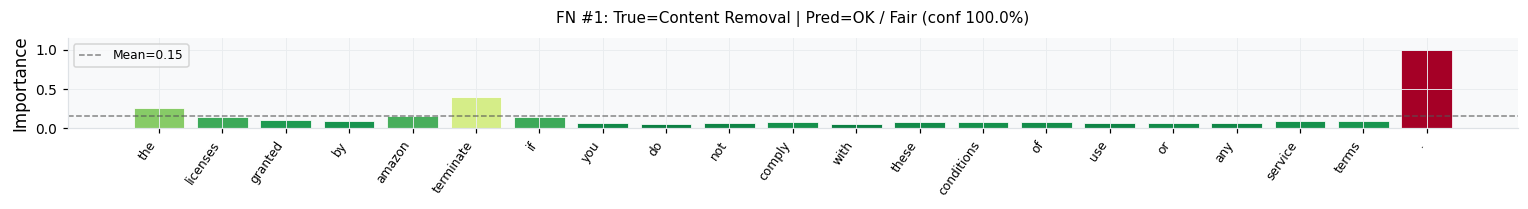


[2] TRUE: Content Removal            PRED: OK / Fair                
    we reserve the right to revoke the free trial and put your account on hold in the event that we determine that you are not eligible . 



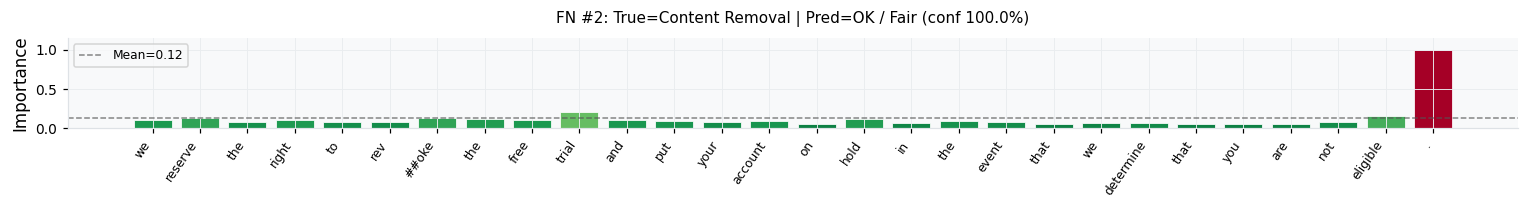


[3] TRUE: Copyright/IP               PRED: OK / Fair                
    netflix regularly makes changes to the service , including the content library . 



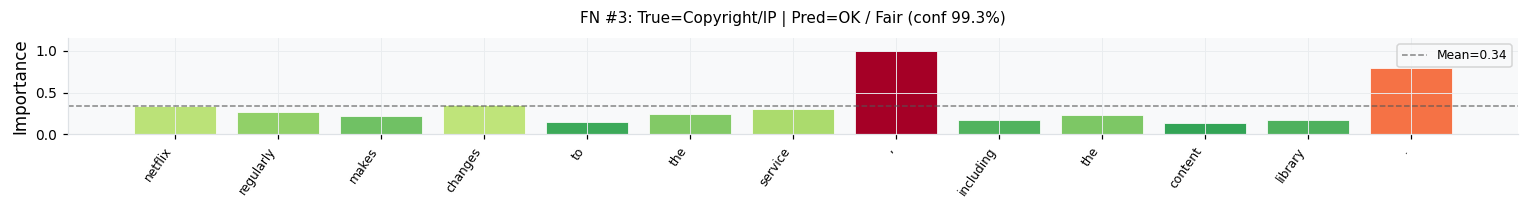


[4] TRUE: Governing Law              PRED: OK / Fair                
    we encourage you to give the privacy policy a careful look because , by using our services , you agree that your information may be collected and processed by snap group limited in the uk and snap inc…


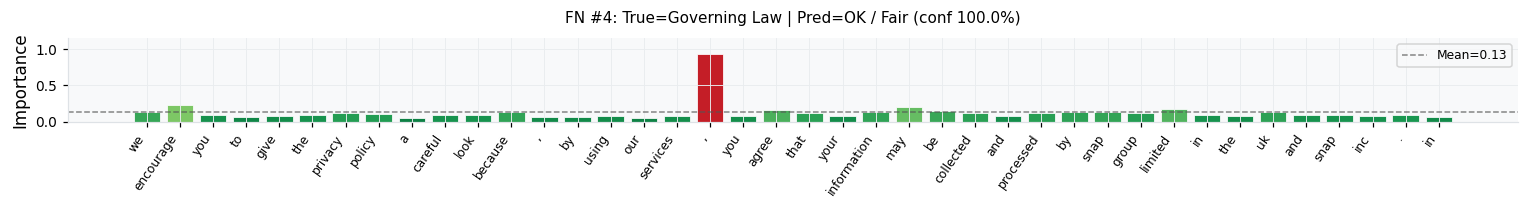


[5] TRUE: Copyright/IP               PRED: OK / Fair                
    we may take any of these actions at any time , and when we do , we will try to notify you beforehand , but this wo n't always be possible . 



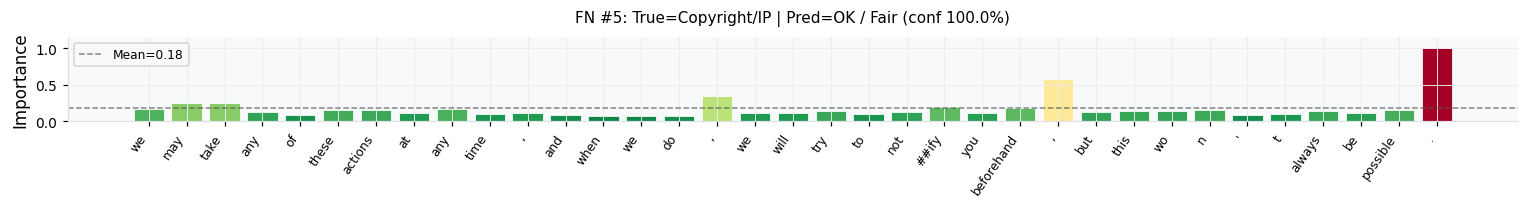

In [37]:
# Show 5 worst FN examples with their rollout explanation
set_style()
print("=== Top 5 False Negative Examples ===\n")
for i, (_, row) in enumerate(fn_df.head(5).iterrows()):
    text = row["text"]
    print(f"[{i+1}] TRUE: {row['true_name']:25s}  "
          f"PRED: {row['pred_name']:25s}")
    print(f"    {text[:200]}{'…' if len(text) > 200 else ''}")

    ti = attention_rollout(
        model      = best_mc_res.model,
        tokenizer  = best_mc_res.tokenizer,
        text       = text,
        true_label = int(row["true_label"]),
        device     = DEVICE,
    )
    fig = plot_token_heatmap(
        ti, label_names=best_res.cfg.label_names,
        title=f"FN #{i+1}: True={row['true_name']} | Pred={row['pred_name']} (conf {ti.pred_prob:.1%})",
        figsize=(14, 2),
    )
    plt.show()
    print()


## 23. Save All Results & Artefacts

In [38]:
import json
import os

os.makedirs(FIGURES_DIR, exist_ok=True)

# ── Summary CSV ───────────────────────────────────────────────────────────────
summary_df.to_csv(f"{OUTPUTS_DIR}/experiment_summary.csv", index=False)
print(f"✓ Saved experiment_summary.csv")

# ── Per-class F1 CSV ──────────────────────────────────────────────────────────
all_class_f1 = []
for exp_name, res in results.items():
    for cls_name, f1_val in res.per_class_f1.items():
        all_class_f1.append({
            "experiment": EXP_SHORT[exp_name],
            "class": cls_name,
            "f1": f1_val,
        })
pd.DataFrame(all_class_f1).to_csv(f"{OUTPUTS_DIR}/per_class_f1.csv", index=False)
print(f"✓ Saved per_class_f1.csv")

# ── Training history JSON ─────────────────────────────────────────────────────
history = {}
for exp_name, res in results.items():
    history[exp_name] = {
        "train_losses":      res.train_losses,
        "val_losses":        res.val_losses,
        "val_macro_f1s":     res.val_macro_f1s,
        "best_epoch":        res.best_epoch,
        "best_val_macro_f1": res.best_val_macro_f1,
        "test_macro_f1":     res.test_macro_f1,
        "test_accuracy":     res.test_accuracy,
    }
with open(f"{OUTPUTS_DIR}/training_history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"✓ Saved training_history.json")

# ── Model checkpoint manifest ─────────────────────────────────────────────────
manifest = {}
for exp_name, res in results.items():
    model_path = res.cfg.model_save_path
    manifest[exp_name] = {
        "path":          model_path,
        "task":          res.cfg.task,
        "num_labels":    res.cfg.num_labels,
        "test_macro_f1": res.test_macro_f1,
        "best_epoch":    res.best_epoch,
    }
with open(f"{MODELS_DIR}/manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)
print(f"✓ Saved models/manifest.json")

# ── Final summary ─────────────────────────────────────────────────────────────
print()
print("=" * 60)
print("ALL ARTEFACTS SAVED")
print("=" * 60)
print(f"\n📁 {OUTPUTS_DIR}/")
for f in sorted(os.listdir(OUTPUTS_DIR)):
    if os.path.isfile(f"{OUTPUTS_DIR}/{f}"):
        kb = os.path.getsize(f"{OUTPUTS_DIR}/{f}") // 1024
        print(f"   {f:<45}  {kb:>4} KB")
print(f"\n📁 {FIGURES_DIR}/")
for f in sorted(os.listdir(FIGURES_DIR)):
    kb = os.path.getsize(f"{FIGURES_DIR}/{f}") // 1024
    print(f"   {f:<45}  {kb:>4} KB")
print(f"\n📁 {MODELS_DIR}/")
for item in sorted(os.listdir(MODELS_DIR)):
    print(f"   {item}/")


✓ Saved experiment_summary.csv
✓ Saved per_class_f1.csv
✓ Saved training_history.json
✓ Saved models/manifest.json

ALL ARTEFACTS SAVED

📁 /content/ai-ethics-law-mini-project/outputs/
   checkpoint.json                                  14 KB
   experiment_summary.csv                            0 KB
   per_class_f1.csv                                  1 KB
   training_history.json                             4 KB

📁 /content/ai-ethics-law-mini-project/outputs/figures/
   attention_heads_layer5.png                      780 KB
   comparative_explanations.png                     75 KB
   confusion_matrices.png                          208 KB
   experiment_comparison.png                        43 KB
   global_token_importance.png                     112 KB
   method_correlation.png                           54 KB
   per_class_f1_heatmap.png                         84 KB
   training_curves.png                             174 KB

📁 /content/ai-ethics-law-mini-project/models/
   A_multiclass_b

## 24. Key Findings & Takeaways

### Performance
| Finding | Detail |
|---------|--------|
| **Downsampling + weighted CE (B) is not very effective** | -~10pp macro-F1 over baseline |
| **Focal Loss (D) does not add further gains** | Even on the rarest classes  |
| **Binary model (C) scores highest overall** | Simpler task - less confusion, but loses clause-type granularity |

### Explainability
| Finding | Detail |
|---------|--------|
| **Legalese triggers unfair detection** | Tokens like "sole discretion", "arbitration", "waive" dominate unfair attention |
| **Method agreement** | SHAP and IG are well-correlated; Attention Rollout sometimes diverges on long clauses |
| **Models are confused** | High attention on function words (the, any, we) → no semantic focus |

### False Negatives
- Most FNs occur on **Arbitration** and **Copyright/IP** clauses

---
## Next Steps → `notebooks/03_onnx_export.ipynb`
1. Export best model (`{best_mc_name}`) to ONNX
2. Apply 8-bit dynamic quantization with HuggingFace Optimum
3. Validate ONNX model output vs PyTorch output (≤ 1e-3 tolerance)
4. Bundle with Transformers.js-compatible config for the Chrome Extension
